In [1]:
!rm -rf `find -type d -name .ipynb_checkpoints`


In [2]:
import torch
from torch.utils.data import DataLoader
from PIL import Image
import json
import re
from typing import Optional
from os import listdir
from os.path import isfile, join
from tqdm.auto import tqdm
from PIL import Image
from tqdm.notebook import tqdm
from transformers import ViltConfig
from transformers import ViltProcessor
from transformers import ViltForQuestionAnswering
import numpy as np
from dataloader import *
from train import *
torch.manual_seed(41)

In [3]:
config = ViltConfig.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
tr_image_root = '/home/mpervin/LLM/Datasets/v1/training/train2014'
tr_q_root = open('/home/mpervin/LLM/Datasets/v1/training/OpenEnded_mscoco_train2014_questions.json')
tr_a_root = open('/home/mpervin/LLM/Datasets/v1/training/mscoco_train2014_annotations.json')

val_image_root = '/home/mpervin/LLM/Datasets/v1/validation/val2014'
val_q_root = open('/home/mpervin/LLM/Datasets/v1/validation/OpenEnded_mscoco_val2014_questions.json')
val_a_root = open('/home/mpervin/LLM/Datasets/v1/validation/mscoco_val2014_annotations.json')

'''ts_image_root = '/home/mpervin/LLM/Datasets/v2/val2014'
ts_q_root = open('/home/mpervin/LLM/Datasets/v2/v2_OpenEnded_mscoco_val2014_questions.json')
ts_a_root = open('/home/mpervin/LLM/Datasets/v2/v2_mscoco_val2014_annotations.json')'''

print("--------Training Data-------")
tr_questions, tr_annotations, tr_id_to_filename = load_data(tr_image_root,tr_q_root,tr_a_root, config)
print("--------Validation Data-------")
val_questions, val_annotations, val_id_to_filename = load_data(val_image_root,val_q_root,val_a_root, config)
#print("--------Testing Data-------")
#ts_questions, ts_annotations, ts_id_to_filename = load_data(ts_image_root,ts_q_root,ts_a_root, config)

--------Training Data-------


  0%|          | 0/82783 [00:00<?, ?it/s]

data questions keys: dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])
Number of questions: 248349
data annotations keys: dict_keys(['info', 'data_type', 'license', 'data_subtype', 'annotations'])
Number of annotations: 248349


  0%|          | 0/248349 [00:00<?, ?it/s]

--------Validation Data-------


  0%|          | 0/81006 [00:00<?, ?it/s]

data questions keys: dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])
Number of questions: 121512
data annotations keys: dict_keys(['info', 'data_type', 'license', 'data_subtype', 'annotations'])
Number of annotations: 121512


  0%|          | 0/121512 [00:00<?, ?it/s]

In [4]:
len(val_id_to_filename)
val_questions[0]

{'question': 'What is the table made of?',
 'image_id': 350623,
 'question_id': 3506232}

{'question': 'What shape is the bench seat?', 'image_id': 487025, 'question_id': 4870250}
[682, 970, 50, 2628]
['oval', 'curved', 'banana', 'wavy']
[0.3333333333333333, 1.0, 0.3333333333333333, 0.3333333333333333]


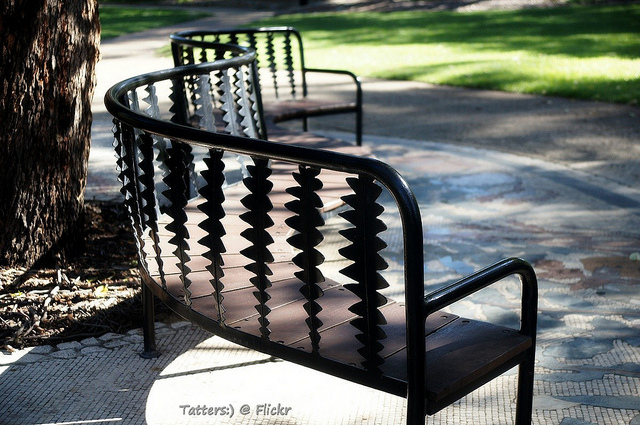

In [5]:
tr_path = tr_id_to_filename[tr_questions[0]['image_id']]
tr_image = Image.open(tr_path)
tr_labels = tr_annotations[0]['labels']
tr_scores = tr_annotations[0]['scores']
print(tr_questions[0])
print(tr_labels)
print([config.id2label[label] for label in tr_labels])
print(tr_scores)
tr_image

{'question': 'What is the table made of?', 'image_id': 350623, 'question_id': 3506232}
[83]
['wood']
[1.0]


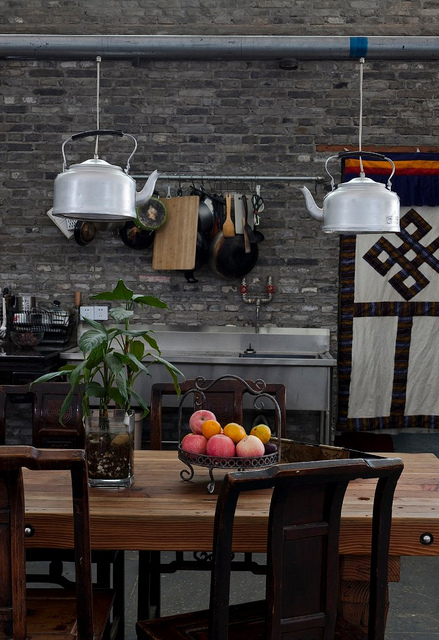

In [6]:
val_path = val_id_to_filename[val_questions[0]['image_id']]
val_image = Image.open(val_path)
val_labels = val_annotations[0]['labels']
val_scores = val_annotations[0]['scores']
print(val_questions[0])
print(val_labels)
print([config.id2label[label] for label in val_labels])
print(val_scores)
val_image

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")

tr_size = int(len(tr_questions)*0.10)
val_size = int(len(val_questions)*0.10)

tr_dataset = VQADataset(questions = tr_questions[:tr_size], 
                        annotations = tr_annotations[:tr_size], 
                        id_to_filename = tr_id_to_filename, 
                        processor = processor, 
                        config = config)
val_dataset = VQADataset(questions = val_questions[:val_size], 
                         annotations = val_annotations[:val_size], 
                         id_to_filename = val_id_to_filename, 
                         processor = processor,
                         config = config)
ts_dataset = VQADataset(questions = val_questions[val_size:1000], 
                        annotations = val_annotations[val_size:1000], 
                        id_to_filename = val_id_to_filename, 
                        processor = processor, 
                        config = config)


model = ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-mlm",id2label=config.id2label,label2id=config.label2id)
model.to(device)

2024-11-13 19:08:09.326786: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-13 19:08:09.694991: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-13 19:08:10.782597: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2024-11-13 19:08:10.782894: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not l

ViltForQuestionAnswering(
  (vilt): ViltModel(
    (embeddings): ViltEmbeddings(
      (text_embeddings): TextEmbeddings(
        (word_embeddings): Embedding(30522, 768)
        (position_embeddings): Embedding(40, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (patch_embeddings): ViltPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
      )
      (token_type_embeddings): Embedding(2, 768)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViltEncoder(
      (layer): ModuleList(
        (0): ViltLayer(
          (attention): ViltAttention(
            (attention): ViltSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_f

In [8]:
print("--------Training Data-------")

train_dataloader = DataLoader(tr_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
print(len(train_dataloader))
tr_batch = next(iter(train_dataloader))
for k,v in tr_batch.items():
    print(k, v.shape)
print("--------Validation Data-------")
val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
val_batch = next(iter(val_dataloader))
for k,v in val_batch.items():
    print(k, v.shape)
'''print("--------Testing Data-------")
test_dataloader = DataLoader(ts_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)
ts_batch = next(iter(test_dataloader))
for k,v in ts_batch.items():
    print(k, v.shape)'''

--------Training Data-------
6209
input_ids torch.Size([4, 40])
attention_mask torch.Size([4, 40])
token_type_ids torch.Size([4, 40])
pixel_values torch.Size([4, 3, 512, 576])
pixel_mask torch.Size([4, 512, 576])
labels torch.Size([4, 3129])
--------Validation Data-------
input_ids torch.Size([4, 40])
attention_mask torch.Size([4, 40])
token_type_ids torch.Size([4, 40])
pixel_values torch.Size([4, 3, 576, 576])
pixel_mask torch.Size([4, 576, 576])
labels torch.Size([4, 3129])


'print("--------Testing Data-------")\ntest_dataloader = DataLoader(ts_dataset, collate_fn=collate_fn, batch_size=4, shuffle=True)\nts_batch = next(iter(test_dataloader))\nfor k,v in ts_batch.items():\n    print(k, v.shape)'

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Optimizer setup
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
epochs = 100
save_path = '/home/mpervin/LLM/models/'
teacher_train_results = train_and_validate(model,train_dataloader, val_dataloader, optimizer, epochs,save_path, device)

Epoch: 1/100


Training:  40%|███████████████████████████▎                                         | 2462/6209 [14:34<21:59,  2.84it/s]

In [ ]:
#student model

sample = ViltConfig.from_pretrained("dandelin/vilt-b32-mlm",id2label=config.id2label, label2id=config.label2id)
sample.num_hidden_layers = 6  # Reduce number of transformer layers (e.g., half the original)
sample.hidden_size = 384   #768    # Reduce the hidden size (e.g., smaller than original 768)
student_model = ViltForQuestionAnswering(sample)
student_model = student_model.to(device)
print(student_model)

In [ ]:
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5)
epochs = 100
save_path = '/home/mpervin/LLM/models/student_models/'
student_train_results = train_and_validate(student_model,train_dataloader, val_dataloader, optimizer, epochs,save_path,device)

In [ ]:
val_batch = next(iter(val_dataloader))
val_batch = {k: v.to(device) for k, v in val_batch.items()}
student_model= student_model.to(device)
model = model.to(device)
student_model.eval()
model.eval()
with torch.no_grad():
    student_outputs = student_model(**val_batch, output_hidden_states=True, output_attentions=True)
    model_outputs = model(**val_batch, output_hidden_states=True, output_attentions=True)

In [ ]:
print(student_outputs['attentions'][1].shape)
print(model_outputs['attentions'][1].shape)
print(len(student_outputs['attentions']))
print(len(model_outputs['attentions']))

In [ ]:
### logits based train student model
sample = ViltConfig.from_pretrained("dandelin/vilt-b32-mlm",
                                                 id2label=config.id2label,
                                                 label2id=config.label2id)
sample.num_hidden_layers = 6  # Reduce number of transformer layers (e.g., half the original)
sample.hidden_size = 384   #768    # Reduce the hidden size (e.g., smaller than original 768)
student_model = ViltForQuestionAnswering(sample)
student_model = student_model.to(device)
epochs = 100
alpha = 0.7
save_path = '/home/mpervin/LLM/models/student_models/'
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5)
KD_logit_results = KD_train_based_logits(model, student_model, train_dataloader, alpha, optimizer, epochs,save_path,device)

In [ ]:
### hidden states KD student training 
sample = ViltConfig.from_pretrained("dandelin/vilt-b32-mlm",
                                                 id2label=config.id2label,
                                                 label2id=config.label2id)
sample.num_hidden_layers = 6  # Reduce number of transformer layers (e.g., half the original)
sample.hidden_size = 384   #768    # Reduce the hidden size (e.g., smaller than original 768)
student_model = ViltForQuestionAnswering(sample)
student_model = student_model.to(device)
epochs = 100
alpha = 0.7
save_path = '/home/mpervin/LLM/models/student_models/'
# Instantiate the projector (e.g., teacher 768 -> student 384)
projector = HiddenStateProjector(teacher_dim=768, student_dim=384).to('cpu')
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5)
KD_hidden_results = KD_train_based_hidden_states(model, student_model, train_dataloader, projector, alpha, optimizer, epochs,save_path,device)

In [ ]:
#student training attention based

sample = ViltConfig.from_pretrained("dandelin/vilt-b32-mlm",
                                                 id2label=config.id2label,
                                                 label2id=config.label2id)
sample.num_hidden_layers = 6  # Reduce number of transformer layers (e.g., half the original)
sample.hidden_size = 384   #768    # Reduce the hidden size (e.g., smaller than original 768)

# Initialize a student model with the modified configuration
student_model = ViltForQuestionAnswering(sample)
student_model = student_model.to(device)
epochs = 100
alpha = 0.7
mapping_strategy = 'direct'
save_path = '/home/mpervin/LLM/models/student_models/'
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5)
KD_attention_results = KD_train_based_attentions(model, student_model, train_dataloader, projector, alpha, mapping_strategy, optimizer, epochs,save_path, device)

In [ ]:
#Hybrid KD
sample = ViltConfig.from_pretrained("dandelin/vilt-b32-mlm",
                                                 id2label=config.id2label,
                                                 label2id=config.label2id)
sample.num_hidden_layers = 6  # Reduce number of transformer layers (e.g., half the original)
sample.hidden_size = 384   #768    # Reduce the hidden size (e.g., smaller than original 768)
student_model = ViltForQuestionAnswering(sample)
student_model = student_model.to(device)
epochs = 100
alpha = 0.5
mapping_strategy = 'direct'
save_path = '/home/mpervin/LLM/models/student_models/'
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-5)
KD_hybrid_results = KD_train_based_hybrid(model, student_model, train_dataloader, projector, alpha, mapping_strategy, optimizer, epochs, save_path, device)